### simple workflow or graph using LnagGraph
Langgraph- LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows

state
First define the state pf the graph
the state schema serves as the input schema for all nodes in the graph

typedict is used for whenevver the graph gets executed it retain all the information inside state scema in the form of dictionary



In [2]:
# %python -m pyppeteer install



In [3]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info:str


In [4]:
%pip install pyppeteer

Note: you may need to restart the kernel to use updated packages.


In [5]:
def start_play(state:State):
    print("start play node has been called")
    return {"graph_info":state["graph_info"] + "i am planning to play "}

def cricket(state:State):
    print("cricket node has been called")
    return {"graph_info":state["graph_info"] + " Cricket"}

def badminton(state:State):
    print("my badminton node has been called")
    return {"graph_info":state["graph_info"] + " Badminton"}

In [6]:
import random
from typing import Literal

def random_play(state:State)-> Literal['cricket','badminton']:
    if random.random()>0.5:
        return "cricket"
    else:
        return "badminton"

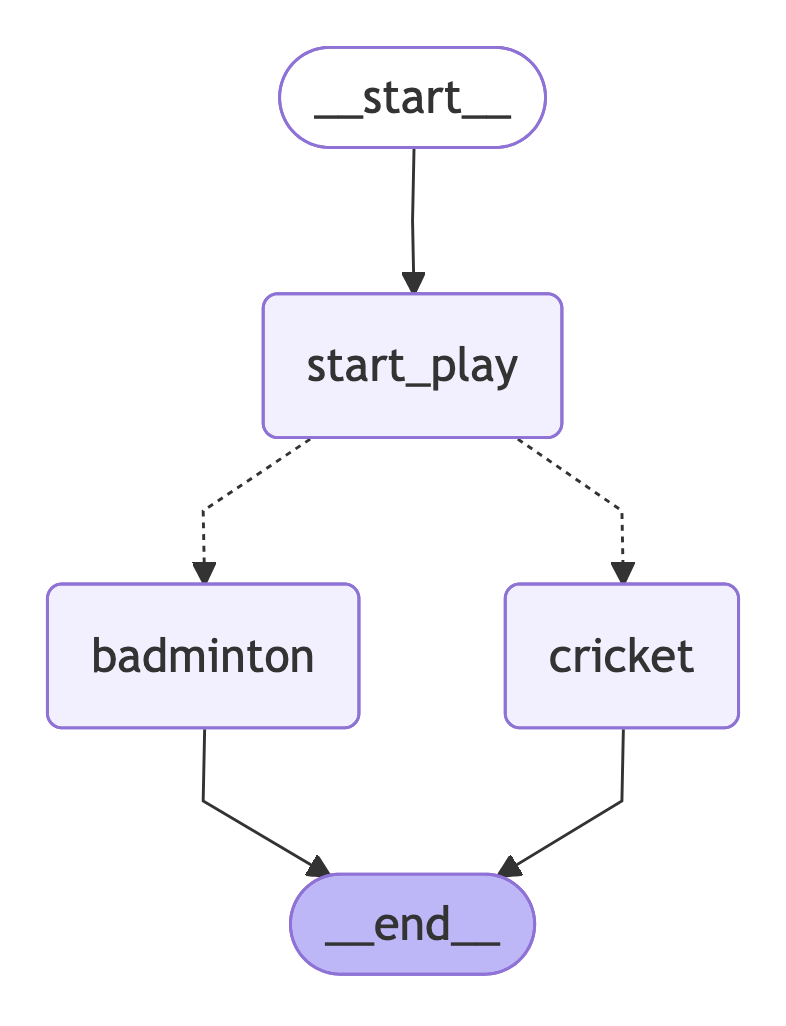

In [7]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langchain_core.runnables.graph import MermaidDrawMethod
import nest_asyncio

nest_asyncio.apply()


##Build graph
graph=StateGraph(State)

##add all the nodes

graph.add_node("start_play",start_play)
graph.add_node("cricket",cricket)
graph.add_node("badminton",badminton)

##Schedule the flow of the graph
graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("cricket",END)
graph.add_edge("badminton",END)

##compile graph
graph_builder=graph.compile()


# Use local pyppeteer renderer (recommended)
img_bytes = graph_builder.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER,
    max_retries=5,
    retry_delay=2.0,
)
display(Image(img_bytes))


#view
# display(Image(graph_builder.get_graph().draw_mermaid_png()))




In [18]:
graph_builder.invoke({"graph_info":"my name is revati"})

start play node has been called
cricket node has been called


{'graph_info': 'my name is revatii am planning to play  Cricket'}